---
Phase 2-3: 用純 NumPy 手刻完整的神經網路
---

這是 Phase 2 最重要的一個檔案。

在你開始用 PyTorch 的 nn.Module 之前，
先用純 NumPy 從頭實作一個能訓練的神經網路。

這樣你才能真正理解：
  - 每一層在做什麼（矩陣乘法 + 激活）
  - 反向傳播怎麼一層一層往回算
  - 權重更新的完整流程

本檔涵蓋：
  1. Layer 類別（Linear + ReLU）
  2. 完整的 NeuralNetwork 類別
  3. 在真實資料上訓練（Iris / Digits）
  4. 和 PyTorch 版本做對比

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. 手刻 Layer 類別
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print("=" * 60)
print("1. 手刻每一層的前向 + 反向傳播")
print("=" * 60)


class LinearLayer:
    """全連接層：z = X @ W + b"""

    def __init__(self, in_features, out_features):
        # He Initialization (適合 ReLU)
        self.W = np.random.randn(in_features, out_features).astype(np.float32) \
                 * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features, dtype=np.float32)

        # 梯度
        self.dW = None
        self.db = None

        # 快取（反向傳播需要用到前向的值）
        self.X_cache = None

    def forward(self, X):
        self.X_cache = X                      # 存起來，backward 要用
        return X @ self.W + self.b            # (batch, out)

    def backward(self, dout):
        """
        dout: 從上一層傳回來的梯度, shape = (batch, out_features)
        回傳: 傳給下一層的梯度, shape = (batch, in_features)
        """
        batch_size = self.X_cache.shape[0]

        # ∂L/∂W = Xᵀ @ dout
        self.dW = self.X_cache.T @ dout / batch_size
        # ∂L/∂b = sum(dout, axis=0)
        self.db = dout.mean(axis=0)
        # ∂L/∂X = dout @ Wᵀ （傳給前一層）
        dX = dout @ self.W.T

        return dX

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db


class ReLULayer:
    """ReLU 激活函數：a = max(0, z)"""

    def __init__(self):
        self.mask = None

    def forward(self, z):
        self.mask = (z > 0).astype(np.float32)   # 記住哪些 > 0
        return z * self.mask

    def backward(self, dout):
        return dout * self.mask    # ReLU 導數：> 0 時為 1，否則為 0


class SoftmaxCrossEntropy:
    """Softmax + Cross-Entropy Loss（合在一起算，梯度公式很簡潔）"""

    def __init__(self):
        self.probs = None
        self.targets = None

    def forward(self, logits, targets):
        """
        logits: (batch, n_classes) — 未經 Softmax 的原始分數
        targets: (batch,) — 正確類別的 index
        """
        # Softmax
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        self.probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        self.targets = targets

        # Cross-Entropy Loss
        batch_size = len(targets)
        correct_log_probs = -np.log(self.probs[np.arange(batch_size), targets] + 1e-8)
        loss = correct_log_probs.mean()
        return loss

    def backward(self):
        """Softmax + CE 的梯度 = probs - one_hot"""
        batch_size = len(self.targets)
        dlogits = self.probs.copy()
        dlogits[np.arange(batch_size), self.targets] -= 1
        return dlogits    # (batch, n_classes)


print("""
每一層的職責：
  LinearLayer:
    前向: z = X @ W + b
    反向: dW = Xᵀ @ dout,  dX = dout @ Wᵀ

  ReLULayer:
    前向: a = max(0, z)
    反向: dz = dout × (z > 0)

  SoftmaxCrossEntropy:
    前向: probs = softmax(logits),  loss = -log(probs[target])
    反向: dlogits = probs - one_hot
""")

1. 手刻每一層的前向 + 反向傳播

每一層的職責：
  LinearLayer:
    前向: z = X @ W + b
    反向: dW = Xᵀ @ dout,  dX = dout @ Wᵀ

  ReLULayer:
    前向: a = max(0, z)
    反向: dz = dout × (z > 0)

  SoftmaxCrossEntropy:
    前向: probs = softmax(logits),  loss = -log(probs[target])
    反向: dlogits = probs - one_hot



## 2. 組合成完整的 NeuralNetwork

In [3]:
print("=" * 60)
print("2. 組合成完整的神經網路")
print("=" * 60)


class NeuralNetwork:
    """
    完整的手刻神經網路
    結構：Linear → ReLU → Linear → ReLU → Linear → Softmax+CE
    """

    def __init__(self, layer_dims):
        """
        layer_dims: e.g., [4, 32, 16, 3] → 4 輸入, 32 隱藏, 16 隱藏, 3 輸出
        """
        self.layers = []
        for i in range(len(layer_dims) - 1):
            self.layers.append(LinearLayer(layer_dims[i], layer_dims[i + 1]))
            if i < len(layer_dims) - 2:   # 最後一層不加 ReLU
                self.layers.append(ReLULayer())

        self.loss_fn = SoftmaxCrossEntropy()
        self.loss_history = []

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out    # logits

    def compute_loss(self, logits, targets):
        return self.loss_fn.forward(logits, targets)

    def backward(self):
        dout = self.loss_fn.backward()
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

    def update(self, lr):
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                layer.update(lr)

    def train_step(self, X, y, lr):
        logits = self.forward(X)
        loss = self.compute_loss(logits, y)
        self.backward()
        self.update(lr)
        return loss

    def predict(self, X):
        logits = self.forward(X)
        return logits.argmax(axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

2. 組合成完整的神經網路


## 3. 在 Iris 資料集上訓練


3. 在 Iris 上訓練手刻神經網路


網路結構: 4 → 32 → ReLU → 16 → ReLU → 3
學習率: 0.1, 迭代: 200

Epoch     Loss  Train Acc   Test Acc
--------------------------------------
    0   1.0655     80.00%     73.33%
   20   0.2714     90.83%     93.33%
   40   0.2027     93.33%     93.33%
   60   0.1627     95.83%    100.00%
   80   0.1351     95.83%    100.00%
  100   0.1150     97.50%    100.00%
  120   0.1004     97.50%    100.00%
  140   0.0895     97.50%    100.00%
  160   0.0815     98.33%    100.00%
  180   0.0752     98.33%    100.00%
  199   0.0704     98.33%    100.00%


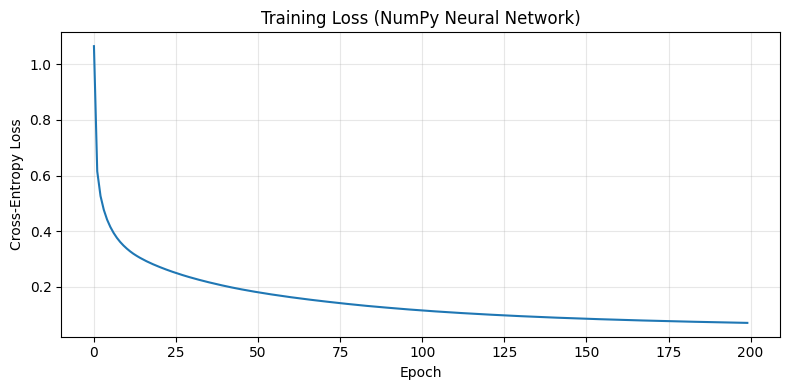


→ 圖表儲存至 plots/03_numpy_nn_loss.png


In [4]:
print("\n" + "=" * 60)
print("3. 在 Iris 上訓練手刻神經網路")
print("=" * 60)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data.astype(np.float32), iris.target

# 標準化
scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立網路：4 → 32 → 16 → 3
np.random.seed(42)
net = NeuralNetwork([4, 32, 16, 3])

# 訓練
lr = 0.1
epochs = 200
print(f"網路結構: 4 → 32 → ReLU → 16 → ReLU → 3")
print(f"學習率: {lr}, 迭代: {epochs}\n")

print(f"{'Epoch':>5} {'Loss':>8} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 38)

for epoch in range(epochs):
    loss = net.train_step(X_train, y_train, lr)
    net.loss_history.append(loss)

    if epoch % 20 == 0 or epoch == epochs - 1:
        train_acc = net.accuracy(X_train, y_train)
        test_acc = net.accuracy(X_test, y_test)
        print(f"{epoch:5d} {loss:8.4f} {train_acc:10.2%} {test_acc:10.2%}")

# 畫 Loss 曲線
plt.figure(figsize=(8, 4))
plt.plot(net.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss (NumPy Neural Network)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/03_numpy_nn_loss.png', dpi=100)
plt.show()
print(f"\n→ 圖表儲存至 plots/03_numpy_nn_loss.png")

## 4. 在 Digits 資料集上訓練（更大的任務）

In [5]:
print("\n" + "=" * 60)
print("4. 在 Digits (手寫辨識) 上訓練")
print("=" * 60)

from sklearn.datasets import load_digits

digits = load_digits()
X_d = digits.data.astype(np.float32)
y_d = digits.target

scaler_d = StandardScaler()
X_d = scaler_d.fit_transform(X_d).astype(np.float32)

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

print(f"Digits: {X_d.shape[1]} 特徵 (8×8 像素), 10 類別")

# 更大的網路：64 → 128 → 64 → 10
np.random.seed(42)
net_digits = NeuralNetwork([64, 128, 64, 10])
lr = 0.05

print(f"網路: 64 → 128 → ReLU → 64 → ReLU → 10\n")
print(f"{'Epoch':>5} {'Loss':>8} {'Train':>8} {'Test':>8}")
print("-" * 34)

for epoch in range(300):
    loss = net_digits.train_step(X_d_train, y_d_train, lr)

    if epoch % 50 == 0 or epoch == 299:
        tr_acc = net_digits.accuracy(X_d_train, y_d_train)
        te_acc = net_digits.accuracy(X_d_test, y_d_test)
        print(f"{epoch:5d} {loss:8.4f} {tr_acc:8.2%} {te_acc:8.2%}")


4. 在 Digits (手寫辨識) 上訓練
Digits: 64 特徵 (8×8 像素), 10 類別
網路: 64 → 128 → ReLU → 64 → ReLU → 10

Epoch     Loss    Train     Test
----------------------------------
    0   3.0121   10.51%    8.61%


   50   0.4084   91.86%   89.72%


  100   0.2075   96.52%   94.17%


  150   0.1365   97.98%   95.28%


  200   0.0999   98.68%   95.83%


  250   0.0773   98.75%   96.39%


  299   0.0624   99.30%   96.39%


## 5. 和 PyTorch 版本對比

In [6]:
print("\n" + "=" * 60)
print("5. PyTorch 等價實作（對照用）")
print("=" * 60)

import torch
import torch.nn as nn

class Net_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.layers(x)

torch.manual_seed(42)
model = Net_PyTorch()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

# 轉成 Tensor
X_tr_t = torch.tensor(X_d_train)
y_tr_t = torch.tensor(y_d_train, dtype=torch.long)
X_te_t = torch.tensor(X_d_test)
y_te_t = torch.tensor(y_d_test, dtype=torch.long)

print(f"{'Epoch':>5} {'Loss':>8} {'Train':>8} {'Test':>8}")
print("-" * 34)

for epoch in range(300):
    # 前向
    logits = model(X_tr_t)
    loss = criterion(logits, y_tr_t)

    # 反向 + 更新
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 299:
        with torch.no_grad():
            tr_acc = (model(X_tr_t).argmax(1) == y_tr_t).float().mean().item()
            te_acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()
        print(f"{epoch:5d} {loss.item():8.4f} {tr_acc:8.2%} {te_acc:8.2%}")

print(f"""
程式碼量對比：
  NumPy 手刻:    ~120 行（LinearLayer + ReLU + SoftmaxCE + Network）
  PyTorch:       ~20 行（nn.Sequential + CrossEntropyLoss + SGD）

  兩者做的是完全一樣的事情。
  但你現在知道 PyTorch 那 20 行背後發生了什麼。
""")


5. PyTorch 等價實作（對照用）


Epoch     Loss    Train     Test
----------------------------------
    0   2.3060   12.39%   11.11%
   50   1.9520   58.04%   57.50%


  100   1.2056   75.71%   75.28%
  150   0.6556   88.24%   86.94%
  200   0.3855   93.74%   90.56%


  250   0.2544   95.62%   92.78%
  299   0.1861   96.24%   94.72%

程式碼量對比：
  NumPy 手刻:    ~120 行（LinearLayer + ReLU + SoftmaxCE + Network）
  PyTorch:       ~20 行（nn.Sequential + CrossEntropyLoss + SGD）

  兩者做的是完全一樣的事情。
  但你現在知道 PyTorch 那 20 行背後發生了什麼。



## 小結

In [7]:
print("=" * 60)
print("小結")
print("=" * 60)
print("""
手刻神經網路教會你的核心理解：

  前向傳播的每一步：
    z = X @ W + b      → 線性變換
    a = ReLU(z)         → 非線性激活
    logits = a @ W + b  → 最後一層
    probs = Softmax(logits)
    loss = -log(probs[target])

  反向傳播的每一步：
    dlogits = probs - one_hot         → Softmax + CE 的梯度
    dW = input.T @ dout               → 權重的梯度
    db = mean(dout)                   → 偏差的梯度
    dinput = dout @ W.T               → 傳給前一層
    dz = dinput * ReLU'(z)            → 通過激活函數

  更新：
    W -= lr * dW
    b -= lr * db

  這就是所有深度學習模型訓練的本質。
  不管模型多大（GPT、Stable Diffusion），都是這個流程。

下一步：04_pytorch_nn_module.py — 用 PyTorch 的方式建構模型
""")

小結

手刻神經網路教會你的核心理解：

  前向傳播的每一步：
    z = X @ W + b      → 線性變換
    a = ReLU(z)         → 非線性激活
    logits = a @ W + b  → 最後一層
    probs = Softmax(logits)
    loss = -log(probs[target])

  反向傳播的每一步：
    dlogits = probs - one_hot         → Softmax + CE 的梯度
    dW = input.T @ dout               → 權重的梯度
    db = mean(dout)                   → 偏差的梯度
    dinput = dout @ W.T               → 傳給前一層
    dz = dinput * ReLU'(z)            → 通過激活函數

  更新：
    W -= lr * dW
    b -= lr * db

  這就是所有深度學習模型訓練的本質。
  不管模型多大（GPT、Stable Diffusion），都是這個流程。

下一步：04_pytorch_nn_module.py — 用 PyTorch 的方式建構模型

